In [53]:
import warnings
from sklearn import metrics
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.rc('font', size=14)
import seaborn as sns
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.preprocessing import scale
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools import add_constant
from sklearn.model_selection import train_test_split
import statsmodels.api as sm
from sklearn import metrics
import statsmodels.stats.api as sms
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, roc_auc_score, classification_report
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import OrdinalEncoder
from sklearn.naive_bayes import CategoricalNB

In [2]:
data = pd.read_csv('default.csv')

In [3]:
data.head()

,Gender,Loan.Offered,Job,Work.Exp,Credit.Score,EMI.Ratio,Status,Credit.History,Own house,Purpose,Dependents
0,Male,0,unskilled,14,86,3.0,No,poor,1,personal,2
1,Female,1,skilled,15,94,3.0,No,poor,1,personal,3
2,Male,0,unskilled,16,86,3.0,No,poor,1,personal,2
3,Female,1,skilled,13,94,3.0,No,poor,1,personal,3
4,Male,1,skilled,12,85,3.3,No,poor,1,personal,2


In [4]:
data.isnull().sum()

Gender            0
Loan.Offered      0
Job               0
Work.Exp          0
Credit.Score      0
EMI.Ratio         0
Status            0
Credit.History    0
Own house         0
Purpose           0
Dependents        0
dtype: int64

In [5]:
data.isna().sum()

Gender            0
Loan.Offered      0
Job               0
Work.Exp          0
Credit.Score      0
EMI.Ratio         0
Status            0
Credit.History    0
Own house         0
Purpose           0
Dependents        0
dtype: int64

In [6]:
data.isin([0]).sum()

Gender              0
Loan.Offered      190
Job                 0
Work.Exp            2
Credit.Score        0
EMI.Ratio           0
Status              0
Credit.History      0
Own house         181
Purpose             0
Dependents        103
dtype: int64

In [7]:
df = data.copy()

### Bivariate analysis

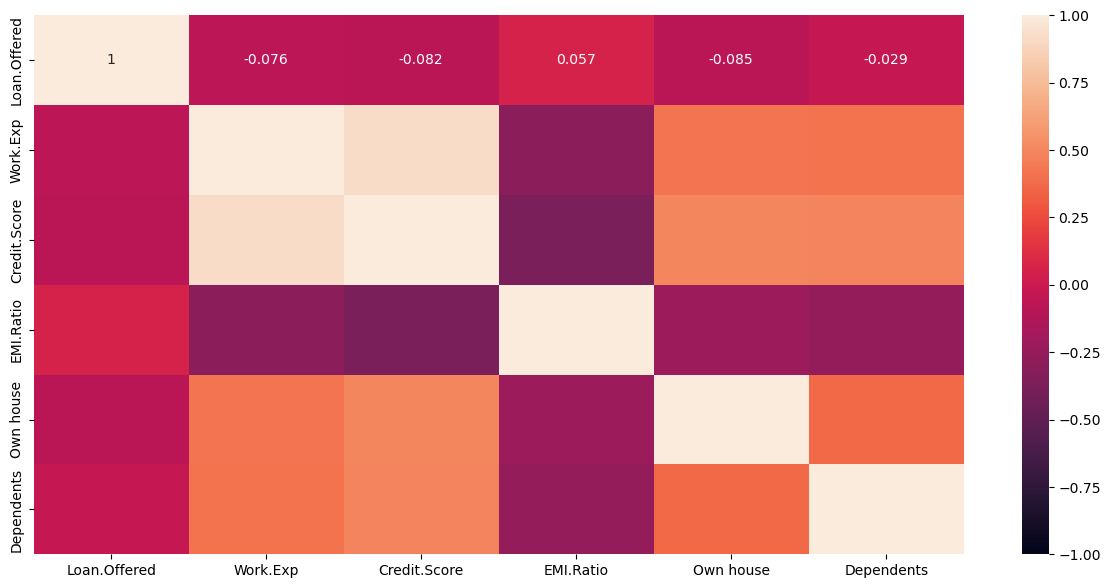

In [8]:
plt.figure(figsize=(15,7))
num_col = data.select_dtypes(include = 'number')
sns.heatmap(num_col.corr(), vmin=-1, vmax=1, annot=True)
plt.show();

C:\Users\Hrishikesh\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\Hrishikesh\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\Hrishikesh\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\Hrishikesh\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to 

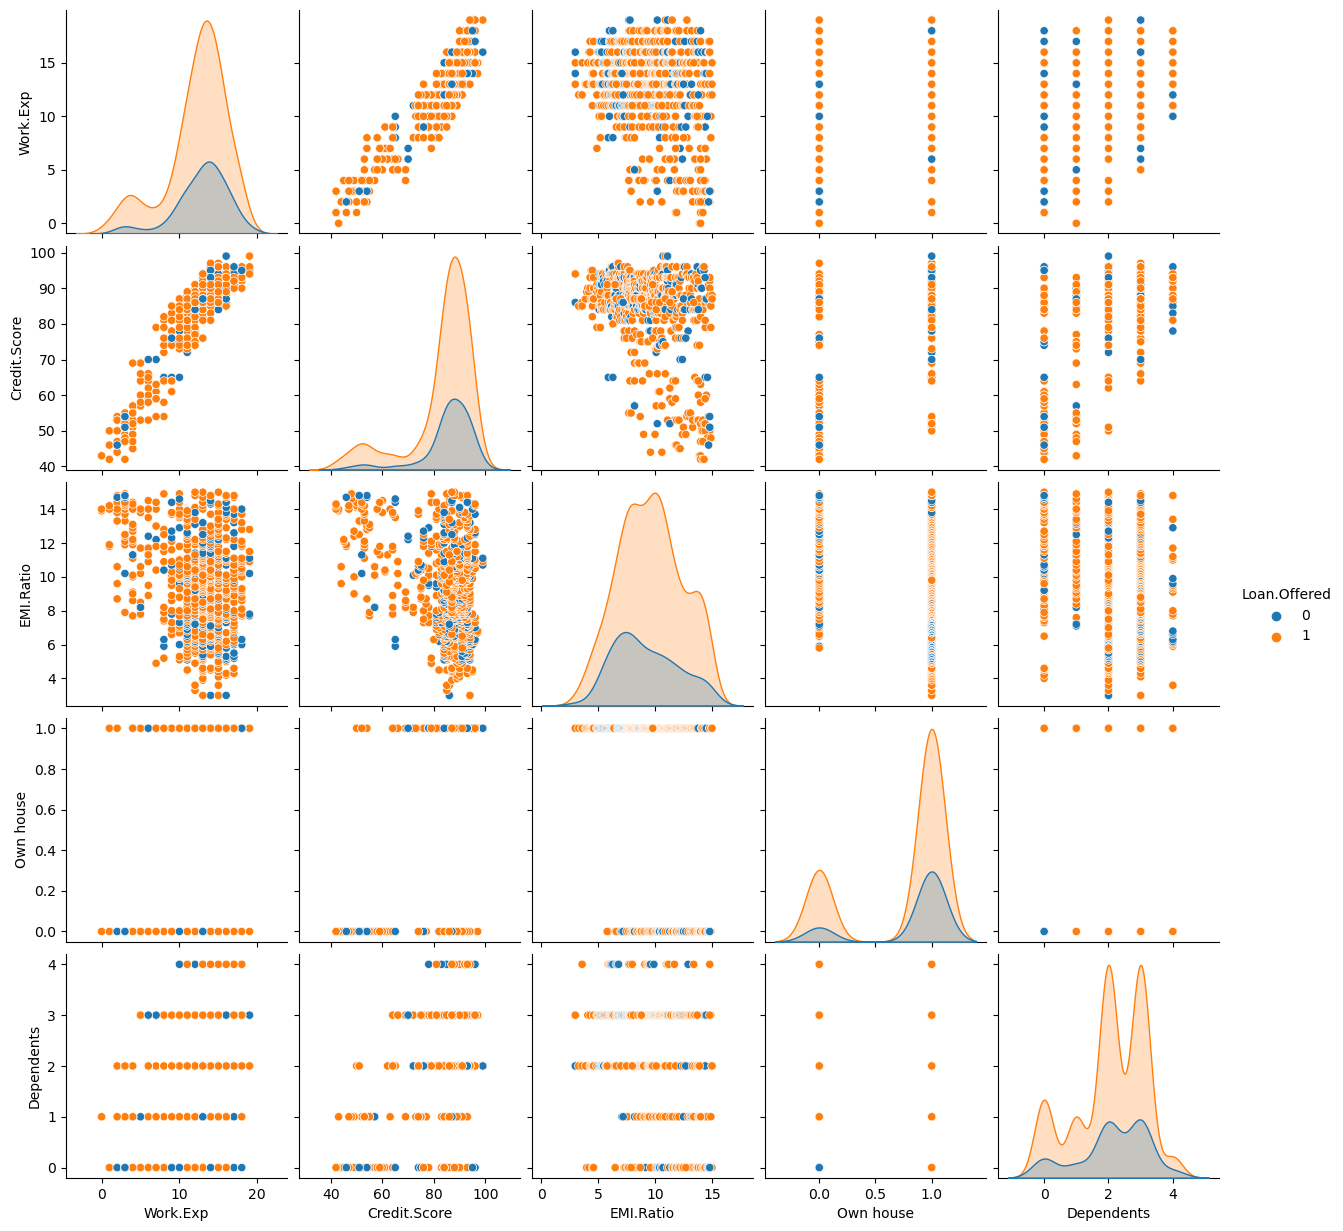

In [9]:
sns.pairplot(data, hue='Loan.Offered')
plt.show();

In [10]:
data['Loan.Offered'].value_counts(1).round(2)*100

Loan.Offered
1    76.0
0    24.0
Name: proportion, dtype: float64

In [11]:
x = data.drop(['Loan.Offered'], axis=1)
y = data['Loan.Offered']
x = add_constant(x)
x = pd.get_dummies(x, drop_first=True).astype(int)
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.3, stratify = y, random_state = 1)

In [12]:
lg = sm.Logit(y_train, x_train).fit()

         Current function value: 0.268183
         Iterations: 35


C:\Users\Hrishikesh\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [13]:
pred_train = np.round(lg.predict(x_train)>0.5)

In [14]:
accuracy_score(y_train, pred_train)

0.891941391941392

In [15]:
cm = confusion_matrix(y_train, pred_train)
custom_cm = pd.DataFrame([[cm[1,1],cm[1,0]],
                          [cm[0,1],cm[0,0]]],
                         columns=['Predicted Positive','Predicted Negative'],
                         index = ['Actual Positive','Actual Negative'])
custom_cm

,Predicted Positive,Predicted Negative
Actual Positive,408,5
Actual Negative,54,79


In [16]:
vif_series = pd.Series([variance_inflation_factor(x_train.values, i) for i in range(x_train.shape[1])],
                       index = x_train.columns,
                       dtype=float)
vif_series

const                       324.701221
Work.Exp                      7.618906
Credit.Score                 10.140516
EMI.Ratio                     2.552264
Own house                     3.168086
Dependents                    3.000512
Gender_Male                   1.803912
Job_skilled                   2.243915
Job_unskilled                 1.958761
Status_No                     4.982284
Credit.History_critical      10.514710
Credit.History_good          18.388140
Credit.History_poor           6.962144
Credit.History_very good     23.497338
Credit.History_verygood       8.058999
Purpose_consumer.durable      5.210207
Purpose_education             7.298947
Purpose_personal              8.261949
dtype: float64

In [17]:
print(lg.summary())

                           Logit Regression Results                           
Dep. Variable:           Loan.Offered   No. Observations:                  546
Model:                          Logit   Df Residuals:                      528
Method:                           MLE   Df Model:                           17
Date:                Tue, 22 Apr 2025   Pseudo R-squ.:                  0.5169
Time:                        07:04:31   Log-Likelihood:                -146.43
converged:                      False   LL-Null:                       -303.13
Covariance Type:            nonrobust   LLR p-value:                 1.916e-56
                               coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------
const                       28.3708   8.42e+04      0.000      1.000   -1.65e+05    1.65e+05
Work.Exp                    -0.1063      0.106     -0.998      0.318      -0.315       0.

In [18]:
x_train1 = x_train.drop(columns=['Job_unskilled',
                                 'Status_No',
                                 'Credit.History_critical',
                                 'Credit.History_good',
                                 'Credit.History_poor',
                                 'Credit.History_very good',
                                 'Credit.History_verygood',
                                 'Purpose_personal'], axis=1)

In [19]:
lg1 = sm.Logit(y_train, x_train1).fit()

Optimization terminated successfully.
         Current function value: 0.379223
         Iterations 7


In [20]:
pred_train1 = np.round(lg1.predict(x_train1))

In [21]:
accuracy_score(y_train, pred_train1)

0.8315018315018315

In [22]:
print(lg1.summary())

                           Logit Regression Results                           
Dep. Variable:           Loan.Offered   No. Observations:                  546
Model:                          Logit   Df Residuals:                      536
Method:                           MLE   Df Model:                            9
Date:                Tue, 22 Apr 2025   Pseudo R-squ.:                  0.3169
Time:                        07:04:31   Log-Likelihood:                -207.06
converged:                       True   LL-Null:                       -303.13
Covariance Type:            nonrobust   LLR p-value:                 1.463e-36
                               coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------
const                        0.7418      1.862      0.398      0.690      -2.908       4.392
Work.Exp                    -0.2045      0.091     -2.243      0.025      -0.383      -0.

In [23]:
vif_series1 = pd.Series([variance_inflation_factor(x_train1.values, i) for i in range(x_train1.shape[1])],
                       index = x_train1.columns,
                       dtype=float)
vif_series1

const                       194.681106
Work.Exp                      7.246208
Credit.Score                  8.780978
EMI.Ratio                     1.589508
Own house                     1.506381
Dependents                    2.124781
Gender_Male                   1.453802
Job_skilled                   1.168067
Purpose_consumer.durable      1.286564
Purpose_education             1.408821
dtype: float64

In [24]:
x_train2 = x_train1.drop(columns=['Credit.Score',
                                  'Purpose_consumer.durable',
                                  'Purpose_education'],axis=1)

In [25]:
lg2 = sm.Logit(y_train, x_train2).fit()

Optimization terminated successfully.
         Current function value: 0.379466
         Iterations 7


In [26]:
pred_train2 = np.round(lg2.predict(x_train2))

In [27]:
print(lg2.summary())

                           Logit Regression Results                           
Dep. Variable:           Loan.Offered   No. Observations:                  546
Model:                          Logit   Df Residuals:                      539
Method:                           MLE   Df Model:                            6
Date:                Tue, 22 Apr 2025   Pseudo R-squ.:                  0.3165
Time:                        07:04:31   Log-Likelihood:                -207.19
converged:                       True   LL-Null:                       -303.13
Covariance Type:            nonrobust   LLR p-value:                 1.012e-38
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
const           0.7885      0.839      0.940      0.347      -0.856       2.433
Work.Exp       -0.2021      0.044     -4.586      0.000      -0.288      -0.116
EMI.Ratio      -0.1073      0.050     -2.151    

In [28]:
odds = np.exp(lg2.params)
pd.DataFrame(odds, x_train2.columns, columns=['odds']).T.round(2)

,const,Work.Exp,EMI.Ratio,Own house,Dependents,Gender_Male,Job_skilled
odds,2.2,0.82,0.9,0.36,2.06,3.92,42.21


In [29]:
perc_change_odds = (np.exp(lg2.params)-1)*100
pd.DataFrame(perc_change_odds, x_train2.columns, columns=['perc_change_odds']).T

,const,Work.Exp,EMI.Ratio,Own house,Dependents,Gender_Male,Job_skilled
perc_change_odds,120.020276,-18.299774,-10.178225,-63.764576,106.294657,291.500026,4120.855393


In [30]:
cm = confusion_matrix(y_train, pred_train2)
custom_cm = pd.DataFrame([[cm[1,1],cm[1,0]],
                          [cm[0,1],cm[0,0]]],
                          columns=['Predicted Positive','Predicted Negative'],
                         index=['Actual Positive','Actual Negative'])
custom_cm

,Predicted Positive,Predicted Negative
Actual Positive,378,35
Actual Negative,58,75


In [31]:
accuracy_score(y_train, pred_train2)

0.8296703296703297

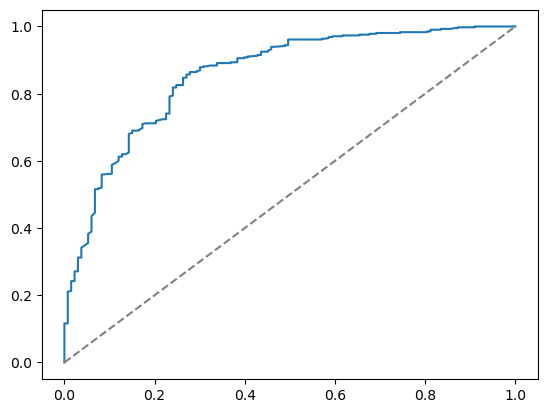

In [32]:
fpr,tpr,_ = roc_curve(y_train, lg2.predict(x_train2))
plt.plot(fpr,tpr)
plt.plot([0,1],[0,1],linestyle='--', color='grey')
plt.show();

In [33]:
auc_score = roc_auc_score(y_train, lg2.predict(x_train2))
auc_score

0.8567059294725918

### Final Model Prediction

In [34]:
x_test = x_test.drop(columns=['Job_unskilled',
                              'Status_No',
                              'Credit.History_critical',
                              'Credit.History_good',
                              'Credit.History_poor',
                              'Credit.History_very good',
                              'Credit.History_verygood',
                              'Purpose_personal',
                              'Credit.Score',
                              'Purpose_consumer.durable',
                              'Purpose_education'],axis=1)

In [35]:
pred_test = np.round(lg2.predict(x_test)>0.5)

In [36]:
accuracy_score(y_test, pred_test)

0.8340425531914893

In [37]:
cm = confusion_matrix(y_test, pred_test)
custom_cm = pd.DataFrame([[cm[1,1],cm[1,0]],
                          [cm[0,1],cm[0,0]]],
                         columns=['Predicted Positive','Predicted Negative'],
                         index = ['Actual Positive','Actual Negative'])
custom_cm

,Predicted Positive,Predicted Negative
Actual Positive,164,14
Actual Negative,25,32


### Naive Bayes Model

In [38]:
df.head()

,Gender,Loan.Offered,Job,Work.Exp,Credit.Score,EMI.Ratio,Status,Credit.History,Own house,Purpose,Dependents
0,Male,0,unskilled,14,86,3.0,No,poor,1,personal,2
1,Female,1,skilled,15,94,3.0,No,poor,1,personal,3
2,Male,0,unskilled,16,86,3.0,No,poor,1,personal,2
3,Female,1,skilled,13,94,3.0,No,poor,1,personal,3
4,Male,1,skilled,12,85,3.3,No,poor,1,personal,2


In [44]:
x_nb = df.drop(['Loan.Offered'], axis=1)
y_nb = df['Loan.Offered']
x_nb = pd.get_dummies(x_nb, drop_first=True)
x_train, x_test, y_train, y_test = train_test_split(x_nb, y_nb, test_size =0.3, stratify = y, random_state = 1)

In [45]:
model = GaussianNB()
model.fit(x_train, y_train.ravel())

GaussianNB()

In [46]:
pred_train = model.predict(x_train)

In [47]:
accuracy_score(y_train, pred_train)

0.891941391941392

In [48]:
cm = confusion_matrix(y_train, pred_train)
custom_cm = pd.DataFrame([[cm[1,1],cm[1,0]],
                          [cm[0,1],cm[0,0]]],
                         columns=['Predicted Positive','Predicted Negative'],
                         index=['Actual Positive','Actual Negative'])
custom_cm

,Predicted Positive,Predicted Negative
Actual Positive,412,1
Actual Negative,58,75


### Predictions on test set

In [49]:
pred_test = model.predict(x_test)

In [50]:
accuracy_score(y_test, pred_test)

0.8851063829787233

In [51]:
cm = confusion_matrix(y_test, pred_test)
custom_cm = pd.DataFrame([[cm[1,1],cm[1,0]],
                          [cm[0,1],cm[0,0]]],
                         columns=['Predicted Positive','Predicted Negative'],
                         index=['Actual Positive','Actual Negative'])
custom_cm

,Predicted Positive,Predicted Negative
Actual Positive,178,0
Actual Negative,27,30


In [52]:
print(classification_report(y_test, pred_test))

              precision    recall  f1-score   support

           0       1.00      0.53      0.69        57
           1       0.87      1.00      0.93       178

    accuracy                           0.89       235
   macro avg       0.93      0.76      0.81       235
weighted avg       0.90      0.89      0.87       235

